In [ ]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import random

# Path ke file hasil "Grand Merger" Anda
HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/2010/STEAD_Indonesia_2010.hdf5'
CSV_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/2010/STEAD_Indonesia_2010_Metadata.csv'

# 1. Baca Buku Indeks (Metadata)
df = pd.read_csv(CSV_PATH)

# Pisahkan daftar nama trace berdasarkan kategorinya
gempa_list = df[df['trace_category'] == 'earthquake_local']['trace_name'].tolist()
noise_list = df[df['trace_category'] == 'noise']['trace_name'].tolist()

# Pilih 1 gempa dan 1 noise secara acak
trace_gempa = random.choice(gempa_list) if gempa_list else None
trace_noise = random.choice(noise_list) if noise_list else None

# Fungsi untuk mem-plot 3 komponen ala STEAD
def plot_waveform(data_array, title):
    # Sumbu X (Waktu) -> 6000 sampel dibagi 100 Hz = 60 detik
    t = np.linspace(0, 60, 6000)
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    komponen = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
    warna = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(3):
        axes[i].plot(t, data_array[:, i], color=warna[i], linewidth=0.8)
        axes[i].set_ylabel(komponen[i], fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    axes[2].set_xlabel("Waktu (Detik)", fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# 2. Buka Brankas HDF5 dan Plot Datanya
with h5py.File(HDF5_PATH, 'r') as hf:
    
    if trace_gempa and trace_gempa in hf:
        print(f"Menggambar Gelombang Gempa: {trace_gempa}")
        data_gempa = hf[trace_gempa][:]
        plot_waveform(data_gempa, f"Kategori: Gempa Bumi Lokal (LE)\nTrace: {trace_gempa}")
        
    if trace_noise and trace_noise in hf:
        print(f"Menggambar Gelombang Bising: {trace_noise}")
        data_noise = hf[trace_noise][:]
        plot_waveform(data_noise, f"Kategori: Seismik Noise (NO)\nTrace: {trace_noise}")

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/STEAD_Indonesia_2004_2010_Final.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori
        le_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

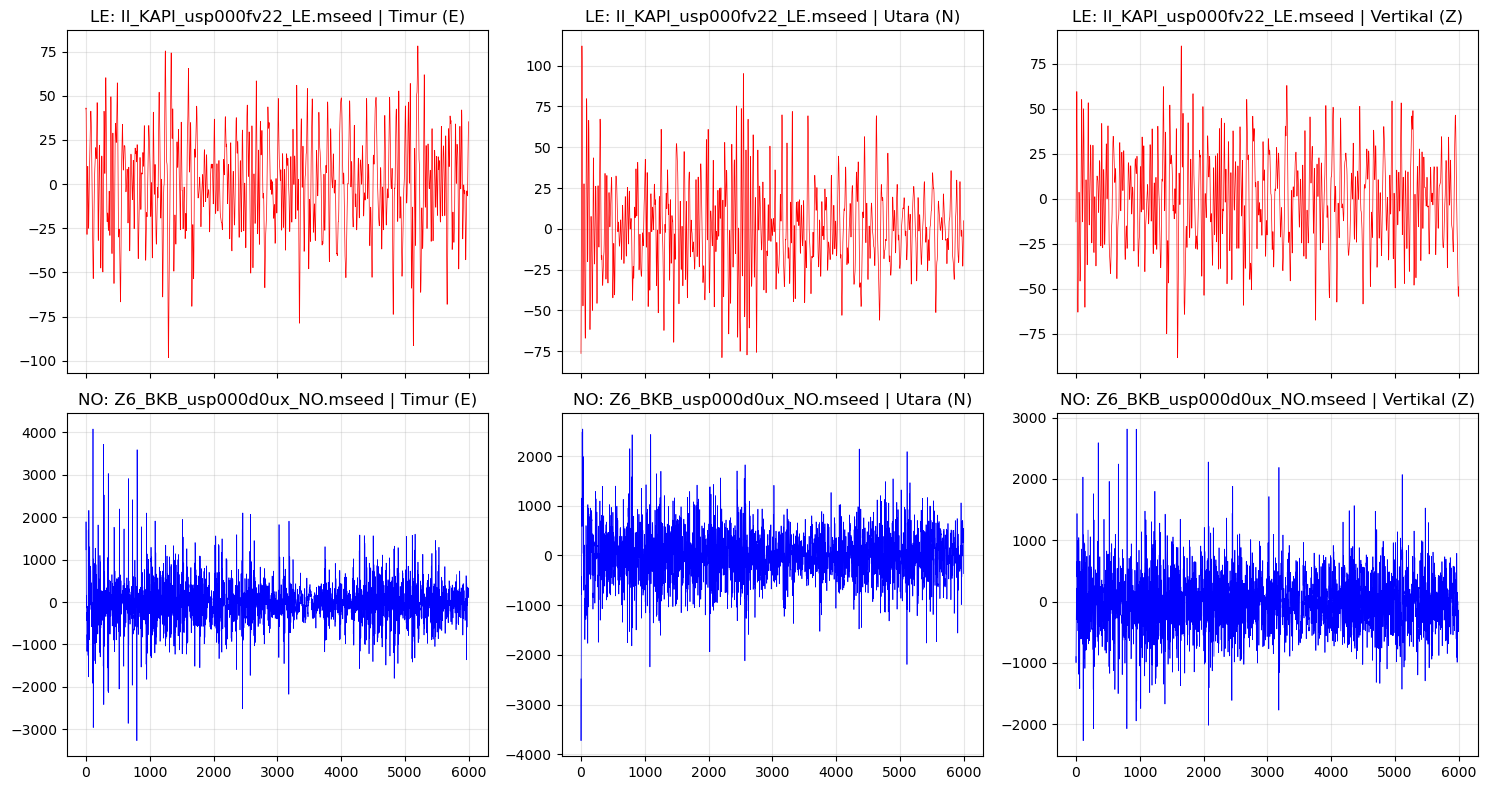

In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori (menggunakan atribut metadata)
        le_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

Membaca data dan memetakan statistik...
Data LE terkumpul: 27849, Data NO terkumpul: 27849


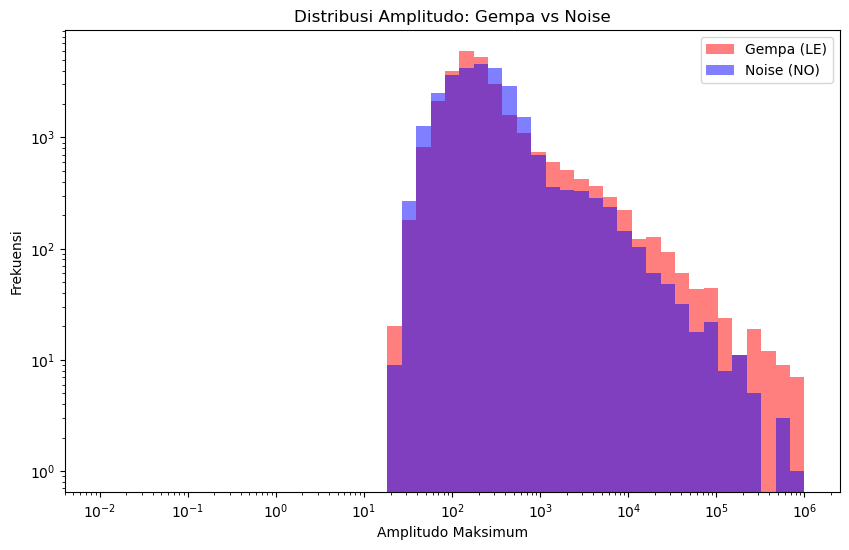

In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def visualize_dataset_stats(h5_path):
    le_amps = []
    no_amps = []
    
    print("Membaca data dan memetakan statistik...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # MENGGUNAKAN ATRIBUT YANG BENAR: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)
                
    print(f"Data LE terkumpul: {len(le_amps)}, Data NO terkumpul: {len(no_amps)}")
    
    if len(le_amps) == 0 or len(no_amps) == 0:
        print("Data masih tidak terdeteksi. Periksa ejaan kategori di atribut.")
        return

    # Plotting
    plt.figure(figsize=(10, 6))
    bins = np.logspace(-2, 6, 50)
    plt.hist(le_amps, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_amps, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum')
    plt.ylabel('Frekuensi')
    plt.title('Distribusi Amplitudo: Gempa vs Noise')
    plt.legend()
    plt.show()

visualize_dataset_stats(HDF5_PATH)

Menganalisis statistik kelas...

--- Analisis Signifikansi ---
Rerata Amplitudo LE: 3063.87
Rerata Amplitudo NO: 1240.34
Perbandingan rasio (LE/NO): 2.47x


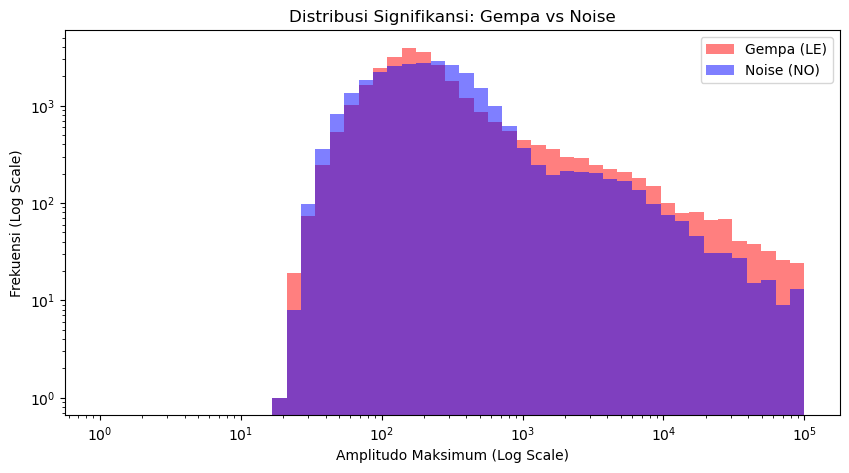

In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def analyze_significance(h5_path):
    le_amps = []
    no_amps = []
    
    print("Menganalisis statistik kelas...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # Menggunakan atribut yang terverifikasi: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)

    # Menghitung statistik dasar
    le_arr = np.array(le_amps)
    no_arr = np.array(no_amps)
    
    print(f"\n--- Analisis Signifikansi ---")
    print(f"Rerata Amplitudo LE: {np.mean(le_arr):.2f}")
    print(f"Rerata Amplitudo NO: {np.mean(no_arr):.2f}")
    print(f"Perbandingan rasio (LE/NO): {np.mean(le_arr)/np.mean(no_arr):.2f}x")
    
    # Visualisasi perbandingan distribusi
    plt.figure(figsize=(10, 5))
    bins = np.logspace(0, 5, 50)
    plt.hist(le_arr, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_arr, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum (Log Scale)')
    plt.ylabel('Frekuensi (Log Scale)')
    plt.title('Distribusi Signifikansi: Gempa vs Noise')
    plt.legend()
    plt.show()

analyze_significance(HDF5_PATH)

In [ ]:
# -*- coding: utf-8 -*-
import os
import collections

# ==============================================================================
# 🎛️ TARGET DIREKTORI DATASET LOKAL INDONESIA BAPAK
# ==============================================================================
PATH_TARGET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

def audit_kompatibilitas_3c_dataset():
    print("="*90)
    print("🔍 STARTING: FORENSIC DATASET AUDIT FOR 3-COMPONENT (3C) COMPATIBILITY")
    print("="*90)
    
    if not os.path.exists(PATH_TARGET_DIR):
        print(f"❌ GALAT: Jalur direktori tidak ditemukan di: {PATH_TARGET_DIR}")
        return

    total_mseed_files = 0
    
    # Dictionary untuk mencatat komponen apa saja yang ada di setiap folder event stasiun
    # Struktur key: (path_folder, prefix_nama_stasiun_event) -> value: set of components ['n', 'e', 'z']
    peta_komponen_stasiun = collections.defaultdict(set)
    
    # Penghitung string akhiran mentah untuk melihat pola penamaan asli file Bapak
    penghitung_akhiran_mentah = collections.Counter()

    print("⏳ Menyisir seluruh subfolder event gempa secara rekursif (os.walk)...")
    for root, dirs, files in os.walk(PATH_TARGET_DIR):
        mseed_in_folder = [f for f in files if f.endswith('.mseed')]
        total_mseed_files += len(mseed_in_folder)
        
        for file_name in mseed_in_folder:
            name_lower = file_name.lower()
            
            # 1. Deteksi komponen spasial secara agnostik
            komponen_ditemukan = None
            if 'z' in name_lower:
                komponen_ditemukan = 'Z'
            elif 'n' in name_lower:
                komponen_ditemukan = 'N'
            elif 'e' in name_lower:
                komponen_ditemukan = 'E'
                
            # 2. Ekstraksi ekstensi/akhiran unik untuk analisis metadata penamaan
            # Contoh: mengambil '_BHZ_LE.mseed' atau '_LE.mseed'
            parts = file_name.split('_')
            if len(parts) >= 2:
                akhiran_key = "_".join(parts[-2:])
                penghitung_akhiran_mentah[akhiran_key] += 1
            else:
                penghitung_akhiran_mentah[file_name] += 1

            # 3. Kelompokkan berdasarkan stasiun unik di dalam subfolder yang sama
            # Kita buat key unik gabungan antara folder root dan base name stasiun (tanpa komponen & tipe)
            # Contoh nama file: II_KAPI_00_BHZ_LE.mseed -> base identifier: II_KAPI_00
            base_identifier = file_name
            for token in ['_bhz', '_bhn', '_bhe', '_hhz', '_hhn', '_hhe', '_z', '_n', '_e', '_le', '_no', '_LE', '_NO']:
                base_identifier = base_identifier.replace(token, '').replace(token.upper(), '')
            
            # Bersihkan sisa ekstensi mseed
            base_identifier = base_identifier.replace('.mseed', '')
            
            if komponen_ditemukan:
                key_stasiun_event = (root, base_identifier)
                peta_komponen_stasiun[key_stasiun_event].add(komponen_ditemukan)

    # 4. Hitung statistik hasil pengelompokan komponen 3C
    stasiun_1c_z_only = 0
    stasiun_3c_lengkap = 0
    stasiun_lainnya = 0
    
    for komponen_set in peta_komponen_stasiun.values():
        if komponen_set == {'Z'}:
            stasiun_1c_z_only += 1
        elif {'N', 'E', 'Z'}.issubset(komponen_set) or komponen_set == {'N', 'E', 'Z'}:
            stasiun_3c_lengkap += 1
        else:
            stasiun_lainnya += 1

    # ==============================================================================
    # 📊 LAPORAN HASIL AUDIT FORENSIK JUPYTER
    # ==============================================================================
    print("\n📊" + "="*36 + " RINGKASAN METADATA DATASET " + "="*36)
    print(f"• Total File MiniSEED (.mseed) Ditemukan : {total_mseed_files} berkas")
    print(f"• Total Folder Event + Stasiun Unik      : {len(peta_komponen_stasiun)} kombinasi")
    print("-" * 90)
    print("📋 SEBARAN STRUKTUR KOMPONEN SEISMIK LOKAL:")
    print(f"  🟢 Paket 1-Komponen (Hanya Z Vertikal Murni) : {stasiun_1c_z_only} paket stasiun")
    print(f"  🔵 Paket 3-Komponen (Lengkap N + E + Z)      : {stasiun_3c_lengkap} paket stasiun")
    print(f"  🟡 Paket Komponen Parsial/Lainnya            : {stasiun_lainnya} paket stasiun")
    print("-" * 90)
    
    print("📋 TOP 5 POLA AKHIRAN NAMA FILE YANG PALING DOMINAN:")
    for akhiran, jumlah in penghitung_akhiran_mentah.most_common(5):
        print(f"  👉 Pattern: *_{akhiran} -> Terdeteksi sebanyak: {jumlah} file")
    print("-" * 90)
    
    # 5. KESIMPULAN OPERASIONAL SEJATI
    print("📢 KESIMPULAN KOMPATIBILITAS DATA:")
    if stasiun_3c_lengkap > 0 and stasiun_3c_lengkap >= (len(peta_komponen_stasiun) * 0.8):
        print("  ✅ DATASET INI MENDUKUNG 3C SEJATI!")
        print("     Mayoritas stasiun memiliki file komponen N, E, dan Z secara lengkap di subfoldernya.")
    elif stasiun_1c_z_only > 0 and stasiun_3c_lengkap == 0:
        print("  ❌ DATASET INI TIDAK MENDUKUNG 3C (MURNI 1C VERTIKAL)!")
        print("     Seluruh berkas di dalam folder Anda murni hanya berisi komponen gelombang vertikal (Z).")
        print("     Jika ingin menjalankan evaluasi 3C sejati, Anda wajib mengunduh file komponen N dan E terlebih dahulu.")
    else:
        print("  ⚠️ DATASET BERSIFAT CAMPURAN (HYBRID)!")
        print(f"     Hanya ada {stasiun_3c_lengkap} stasiun yang lengkap 3C. Sisanya terfragmentasi.")
    print("="*90)

if __name__ == "__main__":
    audit_kompatibilitas_3c_dataset()

📂 Event ID : usp000fe80
📄 File     : GE_UGM_usp000fe80.mseed

📈 Menampilkan Data Mentah (RAW)...


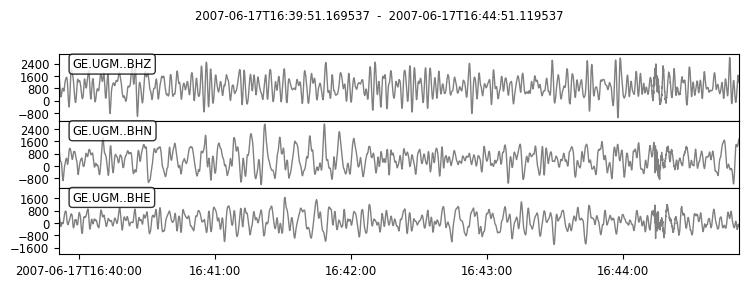

📉 Menampilkan Data Filter (Setelah Detrend & Demean)...


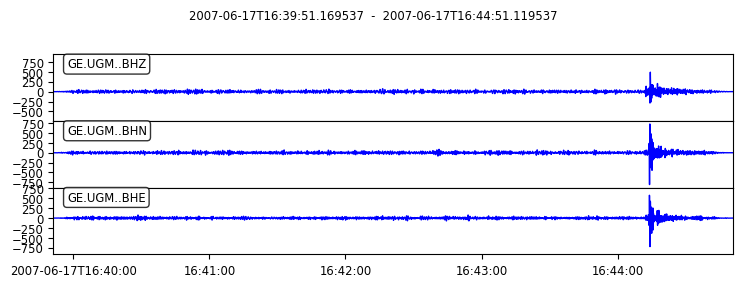

In [57]:
import os
import glob
import random
from obspy import read

# ⚠️ GANTI dengan path BASE_DIR Anda
BASE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'

search_pattern = os.path.join(BASE_DIR, '*', '*', '*.mseed')
mseed_files = glob.glob(search_pattern)

if not mseed_files:
    print("❌ File tidak ditemukan.")
else:
    sample_file = random.choice(mseed_files)
    print(f"📂 Event ID : {os.path.basename(os.path.dirname(sample_file))}")
    print(f"📄 File     : {os.path.basename(sample_file)}\n")
    
    try:
        st = read(sample_file)
        st = st[:3] # Ambil 3 komponen pertama

        print("📈 Menampilkan Data Mentah (RAW)...")
        st.plot(size=(800, 300), color='grey')
        
        # ==========================================
        # 🛠️ LANGKAH PREPROCESSING WAJIB SEBELUM FILTER
        # ==========================================
        st_filtered = st.copy()
        
        # 1. Demean: Tarik semua grafik agar titik tengahnya tepat di 0
        st_filtered.detrend('demean')
        
        # 2. Linear Detrend: Hilangkan tren miring/menanjak akibat sensor drift
        st_filtered.detrend('linear')
        
        # 3. Tapering: Lembutkan 5% ujung awal dan akhir agar filter tidak "kaget" (ringing)
        st_filtered.taper(max_percentage=0.05, type='cosine')
        
        # 4. Baru lakukan Bandpass Filter
        st_filtered.filter('bandpass', freqmin=1.0, freqmax=5.0, corners=4, zerophase=True)
        
        print("📉 Menampilkan Data Filter (Setelah Detrend & Demean)...")
        st_filtered.plot(size=(800, 300), color='blue')
        
    except Exception as e:
        print(f"⚠️ Gagal memproses: {e}")